# # Détection de Deepfakes — CR3 : Conception & Entraînement du Modèle
**Architecture :** EfficientNet-B4 (Transfer Learning) + Agrégation par vidéo  
**Dataset :** ~60 000 images 224×224 (real / fake), splits 80/10/10  
**Filière :** GL4 — INSAT 2025–2026

## 0. Installation des dépendances & Chargement des données prétraitées

In [1]:
!pip install timm albumentations opencv-python-headless scikit-learn matplotlib seaborn tqdm --quiet

In [ ]:
# Données : sortie(s) de preprocess.py (dataset_index.csv + preprocessed/...).
# Sur Kaggle : publier le /kaggle/working de chaque session de prétraitement
# comme dataset, l'ajouter à ce kernel, et lister les racines ici.
from pathlib import Path

DATASET_ROOTS = [
    Path("/kaggle/input/preprocess-run-a"),
    Path("/kaggle/input/preprocess-run-b"),
]


In [ ]:
for root in DATASET_ROOTS:
    assert root.exists(), f"Dataset introuvable : {root}"
    print(root, "->", sorted(p.name for p in root.iterdir()))


## 1. Imports & Configuration

In [4]:
import os
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_curve
)

# ── Reproducibilité ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
# Vérifie que le GPU est compatible avec PyTorch (capability >= 7.0)
# Le Tesla P100 (sm_60) n'est pas supporté par PyTorch >= 2.0 → fallback CPU
def get_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")
    major, minor = torch.cuda.get_device_capability(0)
    if major < 7:
        print(f"[WARN] GPU {torch.cuda.get_device_name(0)} (sm_{major}{minor}) "
              f"non supporté par cette version de PyTorch → utilisation du CPU.")
        return torch.device("cpu")
    return torch.device("cuda")

DEVICE = get_device()
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


## 2. Hyperparamètres & Chemins

In [ ]:
# ── Chemins ──────────────────────────────────────────────────────────────────
# Structure de chaque dataset prétraité (sortie de preprocess.py) :
#   <root>/
#     dataset_index.csv     — colonnes : frame_path, label, video_id, split
#     preprocessed/         — <label>/<video_stem>/frame_XXXXX.jpg (224x224)

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Hyperparamètres (cf. CR3 §6) ─────────────────────────────────────────────
CFG = {
    "model_name"       : "efficientnet_b4",
    "img_size"         : 224,           # redimensionné en 380 en option
    "batch_size"       : 32 if DEVICE.type == "cuda" else 16,
    # Phase 1 – Warmup (backbone gelé)
    "epochs_phase1"    : 5,
    "lr_phase1"        : 1e-4,
    # Phase 2 – Fine-tuning (dernières 2 MBConv + tête)
    "epochs_phase2"    : 15,
    "lr_phase2"        : 1e-5,
    "weight_decay"     : 1e-2,
    "dropout"          : 0.5,
    "early_stop_patience": 5,
    "clf_threshold"    : 0.5,
    "num_workers"      : 4,
}

print(json.dumps(CFG, indent=2))

## 3. Dataset

### 3.1 Construction de l'index (vidéos → frames)

In [ ]:
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# ── Chargement des index produits par preprocess.py ──────────────────────────
def load_index(root: Path) -> pd.DataFrame:
    """Charge dataset_index.csv et ré-ancre les chemins de frames sur ce root
    (les chemins stockés pointent vers le /kaggle/working de la session de
    prétraitement)."""
    csv_candidates = sorted(root.rglob("dataset_index.csv"))
    assert csv_candidates, f"dataset_index.csv introuvable sous {root}"
    df = pd.read_csv(csv_candidates[0])

    def remap(p: str) -> str:
        path = Path(p)
        if path.exists():
            return p
        parts = path.parts
        if "preprocessed" in parts:
            i = parts.index("preprocessed")
            return str(root / Path(*parts[i:]))
        return str(root / path.name)

    df["frame_path"] = df["frame_path"].apply(remap)
    print(f"{csv_candidates[0]} : {len(df)} lignes")
    return df

metadata_df = pd.concat([load_index(r) for r in DATASET_ROOTS], ignore_index=True)

# Déduplication (recouvrement éventuel entre les sessions de prétraitement)
metadata_df["_fname"] = metadata_df["frame_path"].apply(lambda p: Path(p).name)
metadata_df = (metadata_df
               .drop_duplicates(subset=["video_id", "_fname"])
               .drop(columns=["_fname"]))
print(f"Total : {len(metadata_df)} frames, colonnes : {list(metadata_df.columns)}")
print(metadata_df.head())

def build_index(split: str) -> pd.DataFrame:
    """
    Construit un DataFrame pour le split demandé :
        path (str)      — chemin absolu vers l'image
        label (int)     — 0=real, 1=fake
        video_id (str)  — identifiant de la vidéo source (pour l'agrégation)
        split (str)
    Le split 80/10/10 (par vidéo, sans fuite inter-splits) provient de
    preprocess.py.
    """
    df = metadata_df[metadata_df["split"] == split].copy()
    df["path"]  = df["frame_path"]
    df["label"] = df["label"].map({"real": 0, "fake": 1})
    return df[["path", "label", "video_id", "split"]].reset_index(drop=True)

df_train = build_index("train")
df_val   = build_index("val")
df_test  = build_index("test")

for name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    if len(df) == 0:
        print(f"[WARN] {name} : aucune entrée — vérifiez dataset_index.csv.")
    else:
        print(f"{name:5s} | {len(df):>6} frames | {df['video_id'].nunique():>4} vidéos "
              f"| real={(df.label==0).sum():>5} fake={(df.label==1).sum():>5}")


### 3.2 Transforms Albumentations (cf. CR2)

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
IMG_SIZE = CFG["img_size"]

import albumentations as A
import inspect

# Compatibilité albumentations < 1.4 vs >= 1.4 (API renommée)
_ic_params  = inspect.signature(A.ImageCompression.__init__).parameters
_gn_params  = inspect.signature(A.GaussNoise.__init__).parameters
ImageCompression = (
    A.ImageCompression(quality_range=(60, 100), p=0.3)
    if "quality_range" in _ic_params
    else A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3)
)
GaussNoise = (
    A.GaussNoise(std_range=(0.04, 0.2), p=0.3)
    if "std_range" in _gn_params
    else A.GaussNoise(var_limit=(10.0, 50.0), p=0.3)
)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.4),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    ImageCompression,
    GaussNoise,
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print("Transforms définis.")

Transforms définis.


### 3.3 Classe Dataset PyTorch

In [8]:
class DeepfakeFrameDataset(Dataset):
    """Dataset frame-level pour la détection de deepfakes."""

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = cv2.imread(row["path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)["image"]
        label = torch.tensor(row["label"], dtype=torch.float32)
        return image, label, row["video_id"]


train_ds = DeepfakeFrameDataset(df_train, transform=train_transform)
val_ds   = DeepfakeFrameDataset(df_val,   transform=val_transform)
test_ds  = DeepfakeFrameDataset(df_test,  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          shuffle=True,  num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 1350
Val   batches : 172
Test  batches : 171


### 3.4 Visualisation d'un batch

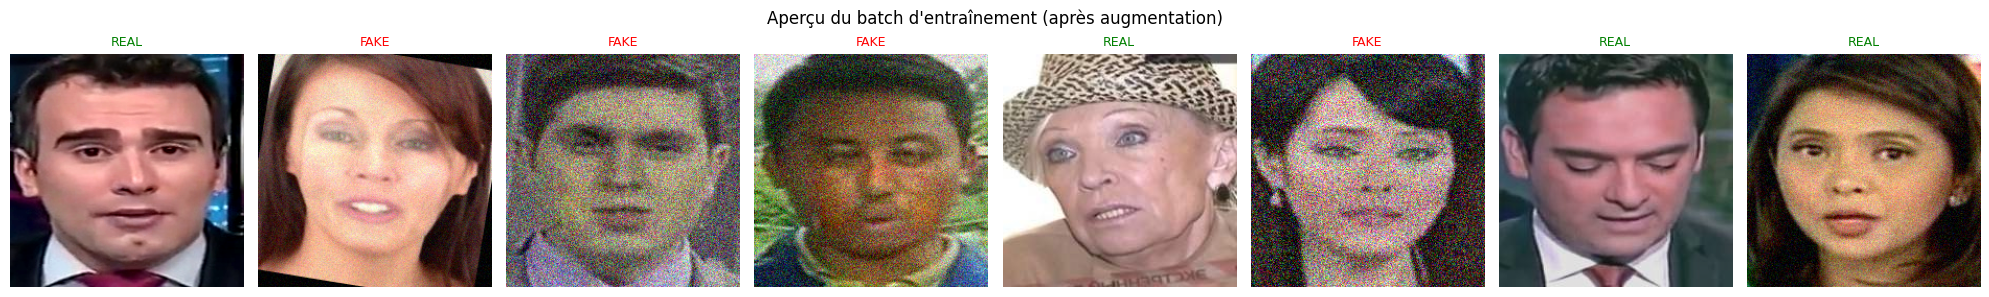

In [9]:
def denormalize(tensor):
    """Inverse la normalisation ImageNet pour affichage."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

images, labels, vids = next(iter(train_loader))
n_show = min(8, len(images))

fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
for i, ax in enumerate(axes):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title("FAKE" if labels[i].item() == 1 else "REAL",
                 color="red" if labels[i].item() == 1 else "green", fontsize=9)
    ax.axis("off")
plt.suptitle("Aperçu du batch d'entraînement (après augmentation)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Modèle : EfficientNet-B4 (cf. CR3 §3)

In [10]:
class DeepfakeDetector(nn.Module):
    """
    EfficientNet-B4 pré-entraîné + tête binaire.
    Architecture tête (CR3 §3.2) :
        GlobalAvgPool (inclus) → Dropout(0.5) → Linear(1792, 1) → Sigmoid
    """

    def __init__(self, dropout: float = 0.5, pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b4",
            pretrained=pretrained,
            num_classes=0,          # retire la tête ImageNet
            global_pool="avg",
        )
        in_features = self.backbone.num_features  # 1792 pour B4
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 1),
        )
        # Sigmoid appliquée à l'inférence (BCEWithLogitsLoss l'inclut à l'entraînement)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, return_logits: bool = True):
        features = self.backbone(x)
        logits   = self.head(features).squeeze(1)
        if return_logits:
            return logits
        return self.sigmoid(logits)

    def freeze_backbone(self):
        """Phase 1 — gèle tout le backbone."""
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_last_mbconv(self, n_blocks: int = 2):
        """
        Phase 2 — libère les n derniers blocs MBConv + BatchNorm finales.
        timm expose les blocs dans backbone.blocks (liste de stages).
        """
        # Dégeler d'abord la BN finale et le conv_head
        for module in [self.backbone.bn2, self.backbone.conv_head]:
            for p in module.parameters():
                p.requires_grad = True
        # Puis les n derniers stages
        stages = list(self.backbone.blocks)
        for stage in stages[-n_blocks:]:
            for p in stage.parameters():
                p.requires_grad = True


model = DeepfakeDetector(dropout=CFG["dropout"]).to(DEVICE)
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux     : {n_total:,}")
print(f"Paramètres entraînables (avant gel) : {n_trainable:,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Paramètres totaux     : 17,550,409
Paramètres entraînables (avant gel) : 17,550,409


## 5. Fonctions d'Entraînement & Évaluation

In [11]:
criterion = nn.BCEWithLogitsLoss()  # numériquement stable, inclut la sigmoid

def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss, all_labels, all_probs = 0.0, [], []

    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(images)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    if scheduler is not None:
        scheduler.step()

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, auc


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, all_labels, all_probs, all_vid_ids = 0.0, [], [], []

    for images, labels, vid_ids in tqdm(loader, desc="Eval ", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * len(images)

        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_vid_ids.extend(vid_ids)

    avg_loss  = total_loss / len(loader.dataset)
    frame_auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, frame_auc, all_probs, all_labels, all_vid_ids


def aggregate_by_video(all_probs, all_labels, all_vid_ids, threshold=0.5):
    """
    Stratégie d'agrégation (CR3 §4) : moyenne des P(fake) par vidéo.
    Retourne un dict {video_id: {score, label, pred}}
    """
    vid_scores  = defaultdict(list)
    vid_labels  = {}
    for prob, label, vid in zip(all_probs, all_labels, all_vid_ids):
        vid_scores[vid].append(prob)
        vid_labels[vid] = int(label)

    results = {}
    for vid, scores in vid_scores.items():
        score = float(np.mean(scores))
        results[vid] = {
            "score" : score,
            "label" : vid_labels[vid],
            "pred"  : int(score > threshold),
        }
    return results


def video_metrics(vid_results):
    labels = [v["label"] for v in vid_results.values()]
    preds  = [v["pred"]  for v in vid_results.values()]
    scores = [v["score"] for v in vid_results.values()]
    return {
        "auc"      : roc_auc_score(labels, scores) if len(set(labels)) > 1 else 0.0,
        "accuracy" : accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall"   : recall_score(labels, preds, zero_division=0),
        "f1"       : f1_score(labels, preds, zero_division=0),
    }

print("Fonctions d'entraînement et d'évaluation définies.")

Fonctions d'entraînement et d'évaluation définies.


## 6. Boucle d'Entraînement (Phase 1 + Phase 2)

In [12]:
history = {"phase": [], "epoch": [],
           "train_loss": [], "train_auc": [],
           "val_loss": [],   "val_auc": []}

best_val_auc = 0.0
patience_counter = 0


def run_phase(phase: int, epochs: int, lr: float, unfreeze_backbone: bool = False):
    global best_val_auc, patience_counter

    print(f"\n{'='*60}")
    print(f"  PHASE {phase} — lr={lr}  epochs={epochs}")
    print(f"{'='*60}")

    if phase == 1:
        model.freeze_backbone()
        print("  Backbone gelé. Seule la tête est entraînée.")
    else:
        model.unfreeze_last_mbconv(n_blocks=2)
        print("  2 derniers blocs MBConv + tête dégelés.")

    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Paramètres entraînables : {n_trainable:,}")

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=CFG["weight_decay"]
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(1, epochs + 1):
        train_loss, train_auc = train_one_epoch(model, train_loader, optimizer, scheduler)
        val_loss, val_auc, val_probs, val_labels, val_vids = evaluate(model, val_loader)
        vid_res = aggregate_by_video(val_probs, val_labels, val_vids, CFG["clf_threshold"])
        vid_met = video_metrics(vid_res)

        history["phase"].append(phase)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_auc"].append(train_auc)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        print(f"  Ép {epoch:02d}/{epochs} | "
              f"Loss train={train_loss:.4f} val={val_loss:.4f} | "
              f"AUC frame train={train_auc:.4f} val={val_auc:.4f} | "
              f"AUC vidéo={vid_met['auc']:.4f}  F1={vid_met['f1']:.4f}")

        # ── Sauvegarde du meilleur modèle ────────────────────────────────────
        if val_auc > best_val_auc:
            best_val_auc     = val_auc
            patience_counter = 0
            ckpt_path = CHECKPOINT_DIR / "best_model.pth"
            # Sauvegarder uniquement le state_dict + scalaires Python purs
            # pour rester compatible avec weights_only=True (PyTorch >= 2.6)
            torch.save({"epoch": int(epoch), "phase": int(phase),
                        "state_dict": model.state_dict(),
                        "val_auc": float(val_auc)}, ckpt_path)
            print(f"    ✔ Meilleur modèle sauvegardé (AUC={val_auc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= CFG["early_stop_patience"]:
                print(f"    ⏹ Early stopping (patience={CFG['early_stop_patience']})")
                break


# ── Phase 1 : Warmup ─────────────────────────────────────────────────────────
run_phase(phase=1, epochs=CFG["epochs_phase1"], lr=CFG["lr_phase1"])

# ── Phase 2 : Fine-tuning ─────────────────────────────────────────────────────
patience_counter = 0   # reset pour la phase 2
run_phase(phase=2, epochs=CFG["epochs_phase2"], lr=CFG["lr_phase2"])


  PHASE 1 — lr=0.0001  epochs=5
  Backbone gelé. Seule la tête est entraînée.
  Paramètres entraînables : 1,793


  Ép 01/5 | Loss train=0.6702 val=0.6473 | AUC frame train=0.6657 val=0.7448 | AUC vidéo=0.8083  F1=0.7590
    ✔ Meilleur modèle sauvegardé (AUC=0.7448)


  Ép 02/5 | Loss train=0.6347 val=0.6222 | AUC frame train=0.7415 val=0.7629 | AUC vidéo=0.8294  F1=0.7407
    ✔ Meilleur modèle sauvegardé (AUC=0.7629)


  Ép 03/5 | Loss train=0.6165 val=0.6100 | AUC frame train=0.7540 val=0.7687 | AUC vidéo=0.8334  F1=0.7527
    ✔ Meilleur modèle sauvegardé (AUC=0.7687)


  Ép 04/5 | Loss train=0.6096 val=0.6022 | AUC frame train=0.7549 val=0.7761 | AUC vidéo=0.8431  F1=0.7700
    ✔ Meilleur modèle sauvegardé (AUC=0.7761)


...

  Ép 11/15 | Loss train=0.2074 val=0.2538 | AUC frame train=0.9734 val=0.9665 | AUC vidéo=0.9881  F1=0.9275
    ✔ Meilleur modèle sauvegardé (AUC=0.9665)


  Ép 12/15 | Loss train=0.2066 val=0.2616 | AUC frame train=0.9736 val=0.9643 | AUC vidéo=0.9873  F1=0.9442


  Ép 13/15 | Loss train=0.2004 val=0.2489 | AUC frame train=0.9752 val=0.9667 | AUC vidéo=0.9889  F1=0.9406
    ✔ Meilleur modèle sauvegardé (AUC=0.9667)


  Ép 14/15 | Loss train=0.2052 val=0.2627 | AUC frame train=0.9740 val=0.9653 | AUC vidéo=0.9873  F1=0.9320


  Ép 15/15 | Loss train=0.2055 val=0.2527 | AUC frame train=0.9739 val=0.9658 | AUC vidéo=0.9879  F1=0.9406


## 7. Courbes d'Entraînement

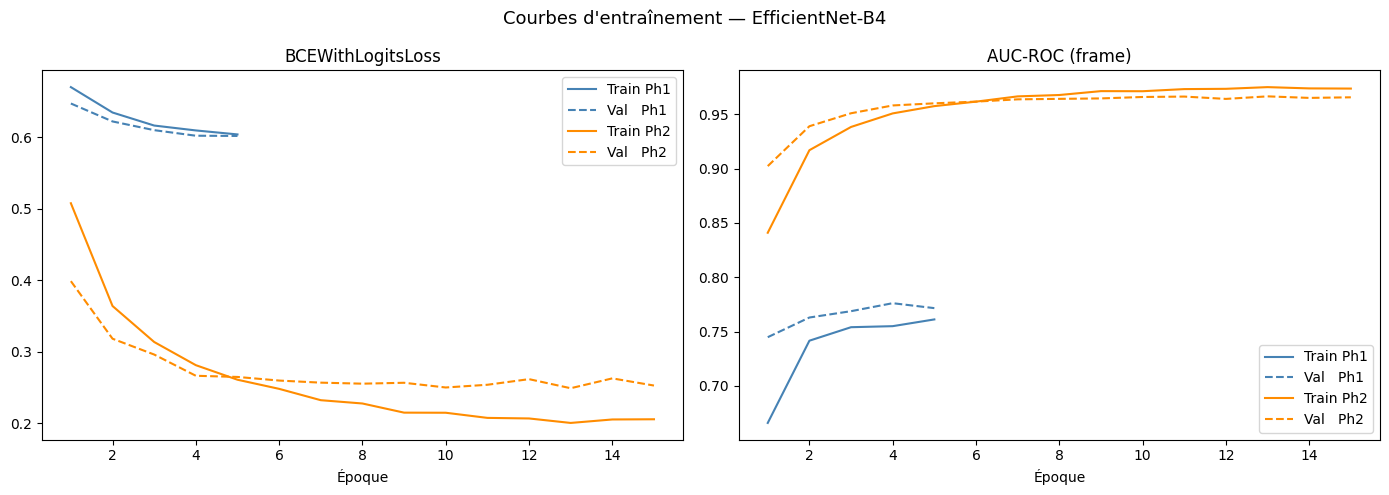

In [13]:
df_hist = pd.DataFrame(history)
phases  = df_hist["phase"].unique()
colors  = {1: "steelblue", 2: "darkorange"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ph in phases:
    sub = df_hist[df_hist["phase"] == ph]
    x   = range(1, len(sub) + 1)
    c   = colors[ph]
    # Loss
    axes[0].plot(x, sub["train_loss"], c=c, linestyle="-",  label=f"Train Ph{ph}")
    axes[0].plot(x, sub["val_loss"],   c=c, linestyle="--", label=f"Val   Ph{ph}")
    # AUC
    axes[1].plot(x, sub["train_auc"],  c=c, linestyle="-",  label=f"Train Ph{ph}")
    axes[1].plot(x, sub["val_auc"],    c=c, linestyle="--", label=f"Val   Ph{ph}")

axes[0].set_title("BCEWithLogitsLoss"); axes[0].set_xlabel("Époque"); axes[0].legend()
axes[1].set_title("AUC-ROC (frame)");   axes[1].set_xlabel("Époque"); axes[1].legend()
plt.suptitle("Courbes d'entraînement — EfficientNet-B4", fontsize=13)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Évaluation sur le Jeu de Test

### 8.1 Chargement du meilleur modèle

In [14]:
ckpt_path = CHECKPOINT_DIR / "best_model.pth"
# weights_only=True est le défaut depuis PyTorch 2.6.
# Notre checkpoint ne contient que state_dict + scalaires Python purs → compatible.
# Si une ancienne version du checkpoint (avec numpy) est présente, on tente le fallback.
try:
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
except Exception:
    print("[WARN] weights_only=True a échoué → rechargement avec weights_only=False (trusted source).")
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
print(f"Modèle chargé — epoch={ckpt['epoch']} phase={ckpt['phase']} val_AUC={ckpt['val_auc']:.4f}")

Modèle chargé — epoch=13 phase=2 val_AUC=0.9667


### 8.2 Prédictions & Agrégation par vidéo

In [15]:
_, _, test_probs, test_labels, test_vids = evaluate(model, test_loader)

vid_results = aggregate_by_video(
    test_probs, test_labels, test_vids, CFG["clf_threshold"]
)
metrics = video_metrics(vid_results)

print("\n── Métriques niveau VIDÉO (jeu de test) ──")
for k, v in metrics.items():
    print(f"  {k:10s} : {v:.4f}")


── Métriques niveau VIDÉO (jeu de test) ──
  auc        : 0.9969
  accuracy   : 0.9750
  precision  : 0.9612
  recall     : 0.9900
  f1         : 0.9754


### 8.3 Matrice de Confusion

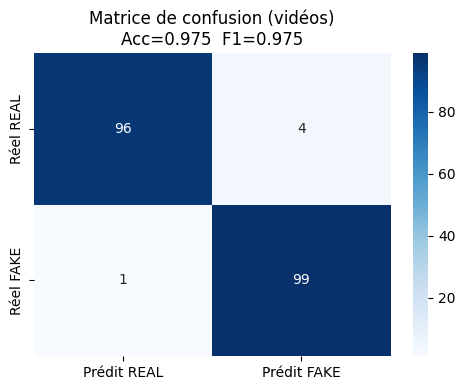

In [16]:
y_true = [v["label"] for v in vid_results.values()]
y_pred = [v["pred"]  for v in vid_results.values()]

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prédit REAL", "Prédit FAKE"],
            yticklabels=["Réel REAL",   "Réel FAKE"], ax=ax)
ax.set_title(f"Matrice de confusion (vidéos)\nAcc={metrics['accuracy']:.3f}  F1={metrics['f1']:.3f}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.4 Courbe ROC

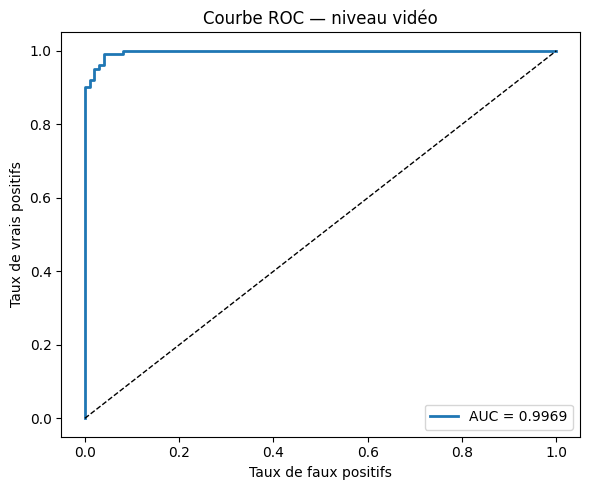

In [17]:
y_scores = [v["score"] for v in vid_results.values()]
fpr, tpr, _ = roc_curve(y_true, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {metrics['auc']:.4f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("Taux de faux positifs"); plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC — niveau vidéo")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.5 Distribution des scores par classe

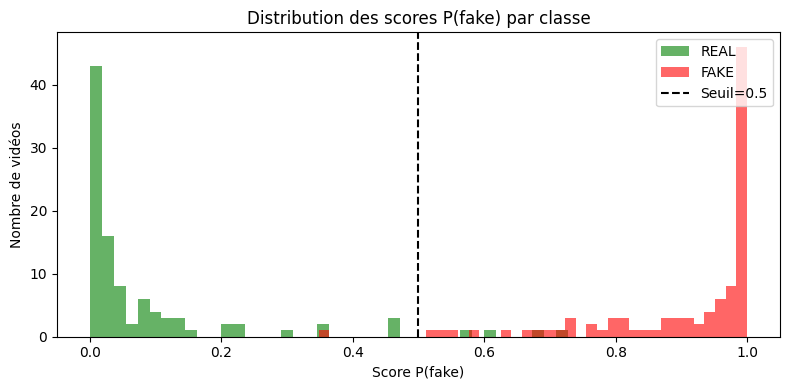

In [18]:
df_vid = pd.DataFrame(vid_results).T
df_vid["score"] = df_vid["score"].astype(float)
df_vid["label"] = df_vid["label"].astype(int)

plt.figure(figsize=(8, 4))
plt.hist(df_vid[df_vid["label"]==0]["score"], bins=40, alpha=0.6, label="REAL",  color="green")
plt.hist(df_vid[df_vid["label"]==1]["score"], bins=40, alpha=0.6, label="FAKE",  color="red")
plt.axvline(CFG["clf_threshold"], color="black", linestyle="--", label=f"Seuil={CFG['clf_threshold']}")
plt.xlabel("Score P(fake)")
plt.ylabel("Nombre de vidéos")
plt.title("Distribution des scores P(fake) par classe")
plt.legend()
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Comparaison des Stratégies d'Agrégation (aperçu CR5)

In [19]:
def aggregate_majority(all_probs, all_labels, all_vid_ids, threshold=0.5):
    vid_scores = defaultdict(list)
    vid_labels = {}
    for prob, label, vid in zip(all_probs, all_labels, all_vid_ids):
        vid_scores[vid].append(prob)
        vid_labels[vid] = int(label)
    results = {}
    for vid, scores in vid_scores.items():
        votes = [int(s > threshold) for s in scores]
        pred  = int(sum(votes) > len(votes) / 2)
        results[vid] = {"score": np.mean(scores), "label": vid_labels[vid], "pred": pred}
    return results


def aggregate_max(all_probs, all_labels, all_vid_ids, threshold=0.5):
    vid_scores = defaultdict(list)
    vid_labels = {}
    for prob, label, vid in zip(all_probs, all_labels, all_vid_ids):
        vid_scores[vid].append(prob)
        vid_labels[vid] = int(label)
    results = {}
    for vid, scores in vid_scores.items():
        score = float(max(scores))
        results[vid] = {"score": score, "label": vid_labels[vid], "pred": int(score > threshold)}
    return results


strategies = {
    "Moyenne (retenue)": aggregate_by_video(test_probs, test_labels, test_vids),
    "Vote majoritaire" : aggregate_majority(test_probs, test_labels, test_vids),
    "Score max"        : aggregate_max(test_probs, test_labels, test_vids),
}

print(f"{'Stratégie':<22} {'AUC':>7} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7}")
print("-" * 58)
for name, res in strategies.items():
    m = video_metrics(res)
    print(f"{name:<22} {m['auc']:>7.4f} {m['accuracy']:>7.4f} "
          f"{m['precision']:>7.4f} {m['recall']:>7.4f} {m['f1']:>7.4f}")

Stratégie                  AUC     Acc    Prec  Recall      F1
----------------------------------------------------------
Moyenne (retenue)       0.9969  0.9750  0.9612  0.9900  0.9754
Vote majoritaire        0.9969  0.9750  0.9612  0.9900  0.9754
Score max               0.9933  0.8200  0.7353  1.0000  0.8475


## 10. Export du Modèle

In [20]:
# ── Sauvegarde du modèle final ────────────────────────────────────────────────
final_path = CHECKPOINT_DIR / "efficientnet_b4_deepfake_final.pth"
# Ne stocker que state_dict + types Python purs (pas de numpy) → weights_only=True compatible
torch.save({
    "state_dict" : model.state_dict(),
    "cfg"        : CFG,
    "best_val_auc": float(best_val_auc),
}, final_path)
# Sauvegarder les métriques et l'historique séparément en JSON (lisible, sans pickle)
import json
with open(CHECKPOINT_DIR / "metrics.json", "w") as f:
    json.dump({"metrics": metrics, "history": history}, f, indent=2)
print(f"Modèle exporté  → {final_path}")
print(f"Métriques JSON  → {CHECKPOINT_DIR / 'metrics.json'}")

# ── Export ONNX (optionnel) ────────────────────────────────────────────────────
try:
    model.eval()
    dummy = torch.randn(1, 3, CFG["img_size"], CFG["img_size"]).to(DEVICE)
    onnx_path = CHECKPOINT_DIR / "efficientnet_b4_deepfake.onnx"
    torch.onnx.export(
        model, dummy, str(onnx_path),
        input_names=["image"], output_names=["logit"],
        dynamic_axes={"image": {0: "batch"}, "logit": {0: "batch"}},
        opset_version=17,
    )
    print(f"ONNX exporté    → {onnx_path}")
except Exception as e:
    print(f"Export ONNX ignoré : {e}")

Modèle exporté  → checkpoints/efficientnet_b4_deepfake_final.pth
Métriques JSON  → checkpoints/metrics.json
Export ONNX ignoré : No module named 'onnxscript'


## Conclusion

Ce notebook implémente le pipeline complet décrit dans le CR3 :

| Étape | Implémentation |
|---|---|
| Dataset | Index vidéo → frames avec `DeepfakeFrameDataset` |
| Augmentation | Albumentations (flip, rotation, ColorJitter, compression, GaussNoise) |
| Backbone | `timm` EfficientNet-B4 pré-entraîné ImageNet |
| Tête | Dropout(0.5) → Linear(1792, 1) → Sigmoid |
| Entraînement | 2 phases : warmup (backbone gelé) + fine-tuning (2 MBConv) |
| Perte | `BCEWithLogitsLoss` |
| Optimiseur | AdamW + CosineAnnealingLR + Early Stopping |
| Agrégation | Moyenne P(fake) par vidéo (+ comparaison vote & max) |
| Métriques | AUC-ROC, Acc, Precision, Recall, F1, matrice de confusion |

**Prochaine étape (CR4)** : analyse des courbes de loss/accuracy et premiers résultats comparatifs.